In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv('S&P_500_Stock_Prices_2014_2017.csv')

In [5]:
df

,symbol,date,open,high,low,close,volume
0,VZ,2014-02-24,47.0200,47.2000,46.23,46.2300,618237630
1,GE,2015-11-17,30.5700,30.7500,30.00,30.3200,431332632
2,BAC,2016-02-11,11.4600,11.5500,10.99,11.1600,375088650
3,GE,2015-04-10,27.1300,28.6800,27.00,28.5100,352701949
4,BAC,2014-04-28,15.3300,15.4100,14.86,14.9500,344935158
...,...,...,...,...,...,...,...
497456,BHF,2017-07-19,67.9200,69.5100,67.80,68.9500,1805
497457,BHF,2017-07-21,70.0000,70.0000,68.56,68.9226,1562
497458,BHF,2017-07-25,69.1461,69.1461,68.95,69.0842,1362
497459,WRK,2015-06-29,60.9200,60.9200,60.80,60.8000,300


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 497461 entries, 0 to 497460
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497461 non-null  str    
 1   date    497461 non-null  str    
 2   open    497461 non-null  float64
 3   high    497461 non-null  float64
 4   low     497461 non-null  float64
 5   close   497461 non-null  float64
 6   volume  497461 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 26.6 MB


In [7]:
df.shape

(497461, 7)

In [8]:
df.describe().round()

,open,high,low,close,volume
count,497461.0,497461.0,497461.0,497461.0,497461.0
mean,86.0,87.0,86.0,86.0,4253695.0
std,101.0,102.0,101.0,101.0,8232210.0
min,2.0,2.0,2.0,2.0,101.0
25%,42.0,42.0,41.0,42.0,1080183.0
50%,65.0,66.0,64.0,65.0,2085013.0
75%,98.0,99.0,98.0,98.0,4271999.0
max,2044.0,2068.0,2035.0,2049.0,618237630.0


In [13]:
df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [14]:
df[df.duplicated()].shape

(0, 7)

In [ ]:
df['date']

In [50]:
df['date'] = pd.to_datetime(df['date'])

In [51]:
df.dtypes

symbol               str
date      datetime64[us]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

## S&P 500 Stock Prices Analysis (2014–2017)

1. Which date saw the largest overall trading volume?
2. On which day of the week is volume highest / lowest, on average?
3. On which date did Amazon (AMZN) see the most volatility (high − low)?
4. Which single stock, bought on 1/2/2014 and held to 12/29/2017, would have delivered the best return?

# 1. Which date saw the largest overall trading volume?

In [18]:
daily_volume = df.groupby('date')['volume'].sum().sort_values(ascending=False)
daily_volume.head(10).to_frame('total_volume')

,total_volume
date,
2015-08-24,4607945196
2016-06-24,4367393052
2015-12-18,4124454411
2016-01-20,4087629753
2016-11-10,4060601612
2014-10-15,3993171524
2015-09-18,3962050449
2016-11-09,3915089371
2016-01-15,3787884056


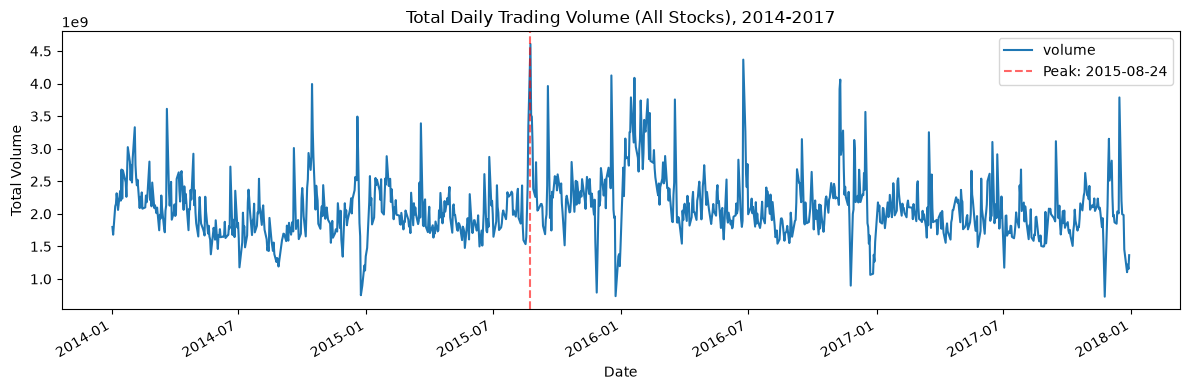

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
top_date = daily_volume.idxmax()
top_volume = daily_volume.max()
daily_volume.sort_index().plot(ax=ax)
ax.set_title('Total Daily Trading Volume (All Stocks), 2014-2017')
ax.set_xlabel('Date')
ax.set_ylabel('Total Volume')
ax.axvline(top_date, color='red', linestyle='--', alpha=0.6, label=f'Peak: {top_date.date()}')
ax.legend()
plt.tight_layout()
plt.show()

## 2) On which day of the week does volume tend to be highest? Lowest?

In [47]:
daily_volume_df = daily_volume.rename('total_volume').to_frame()
daily_volume_df['weekday'] = daily_volume_df.index.day_name()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_by_weekday = (
    daily_volume_df.groupby('weekday')['total_volume']
    .mean()
    .reindex(weekday_order)
    .dropna()
)

print("Average total daily volume by weekday:")
display(avg_by_weekday.to_frame('avg_total_volume'))

highest_day = avg_by_weekday.idxmax()
lowest_day = avg_by_weekday.idxmin()

Average total daily volume by weekday:


,avg_total_volume
weekday,
Monday,"1,991,205,869.78"
Tuesday,"2,069,067,973.93"
Wednesday,"2,123,618,772.80"
Thursday,"2,123,941,009.38"
Friday,"2,191,695,033.16"


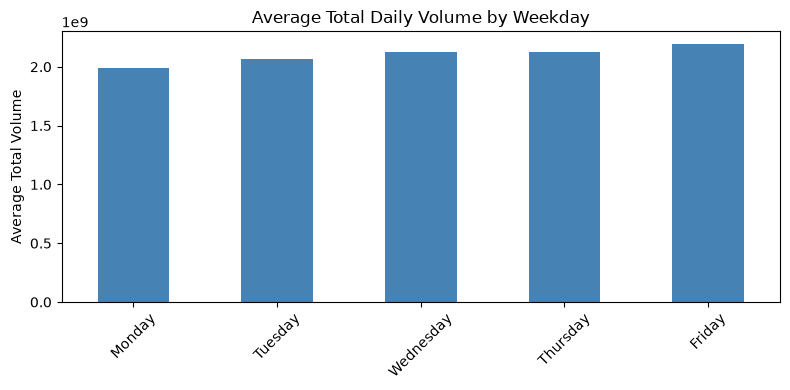

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
avg_by_weekday.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Average Total Daily Volume by Weekday')
ax.set_ylabel('Average Total Volume')
ax.set_xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3) On which date did Amazon (AMZN) see the most volatility (high − low)?

In [53]:
amzn = df[df['symbol'] == 'AMZN'].copy()
amzn['range'] = amzn['high'] - amzn['low']

most_volatile = amzn.loc[amzn['range'].idxmax()]
print(f"Most volatile AMZN date: {most_volatile['date'].date()}")
amzn.sort_values('range', ascending=False)[['date', 'open', 'high', 'low', 'close', 'volume', 'range']].head(10)

Most volatile AMZN date: 2017-06-09


,date,open,high,low,close,volume,range
60174,2017-06-09,"1,012.50","1,012.99",927.00,978.31,7647692,85.99
29675,2016-11-10,778.81,778.83,717.70,742.38,12746994,61.13
20292,2017-10-27,"1,058.14","1,105.58","1,050.55","1,100.95",16565021,55.03
13195,2015-07-24,578.99,580.57,529.35,529.42,21909381,51.22
46270,2017-11-29,"1,194.80","1,194.80","1,145.19","1,161.27",9257512,49.61
83943,2017-12-04,"1,173.85","1,175.20","1,128.00","1,133.95",5931915,47.20
36501,2017-07-27,"1,069.55","1,083.31","1,040.18","1,046.00",10991715,43.13
60089,2016-01-13,620.88,620.88,579.16,581.81,7655239,41.72
25830,2016-01-28,608.37,638.06,597.55,635.35,14015171,40.51
41036,2015-08-24,463.58,489.76,451.00,463.37,10097601,38.76


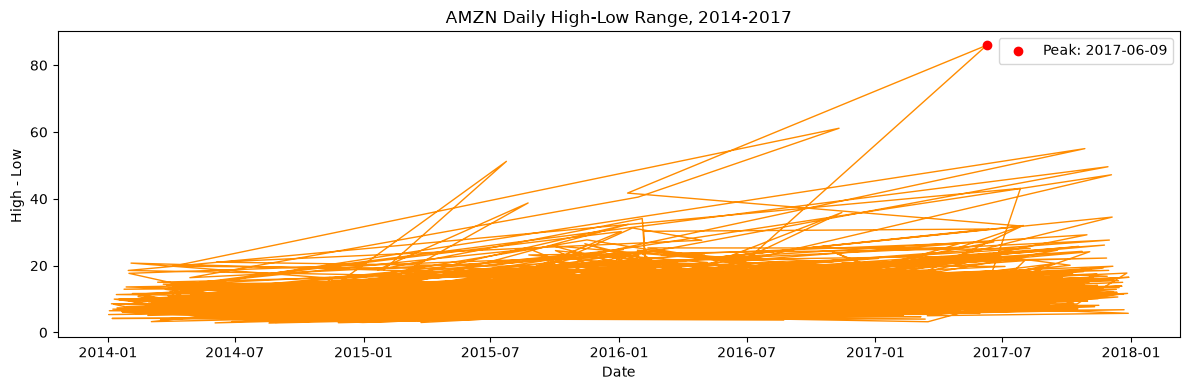

In [55]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(amzn['date'], amzn['range'], color='darkorange', linewidth=1)
ax.scatter([most_volatile['date']], [most_volatile['range']], color='red', zorder=5,
           label=f"Peak: {most_volatile['date'].date()}")
ax.set_title('AMZN Daily High-Low Range, 2014-2017')
ax.set_xlabel('Date')
ax.set_ylabel('High - Low ')
ax.legend()
plt.tight_layout()
plt.show()

## 4) Best single stock to buy-and-hold from 1/2/2014 to 12/29/2017

Stocks with prices on both 2014-01-02 and 2017-12-29: 483


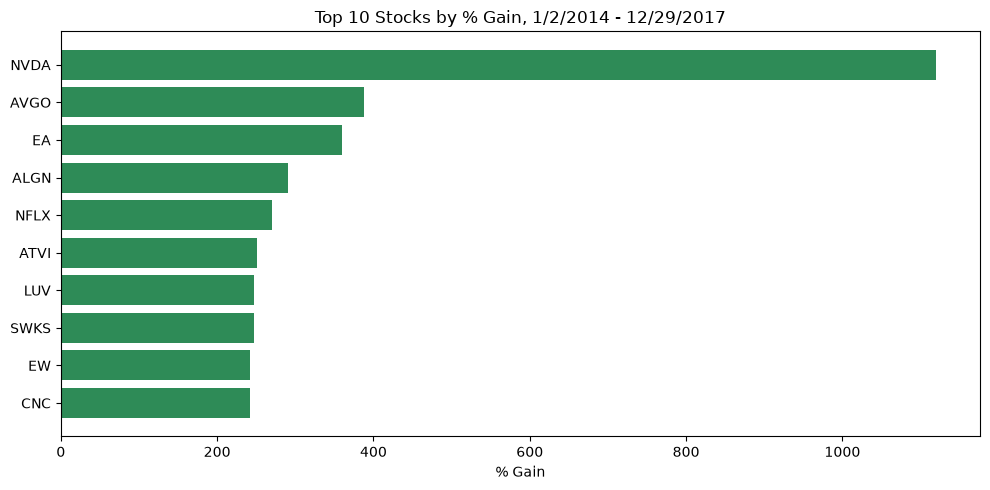

In [64]:
start_date = pd.Timestamp('2014-01-02')
end_date = pd.Timestamp('2017-12-29')

start_prices = df[df['date'] == start_date].set_index('symbol')['close']
end_prices = df[df['date'] == end_date].set_index('symbol')['close']

common_symbols = start_prices.index.intersection(end_prices.index)
print(f"Stocks with prices on both {start_date.date()} and {end_date.date()}: {len(common_symbols)}")

returns = pd.DataFrame({
    'start_price': start_prices.loc[common_symbols],
    'end_price': end_prices.loc[common_symbols],
})
returns['pct_gain'] = (returns['end_price'] - returns['start_price']) / returns['start_price'] * 100
returns = returns.sort_values('pct_gain', ascending=False)

best_symbol = returns.index[0]
best_gain = returns.iloc[0]['pct_gain']

top10 = returns.head(10)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10.index[::-1], top10['pct_gain'][::-1], color='seagreen')
ax.set_title('Top 10 Stocks by % Gain, 1/2/2014 - 12/29/2017')
ax.set_xlabel('% Gain')
plt.tight_layout()
plt.show()